# Customer Churn Prediction & Segmentation for a Digital Bank

## Project Overview
Digital banks compete fiercely for customer loyalty in an environment where switching providers
is nearly frictionless. This project analyze the functions of a digital bank
and answer a concrete business question:

> “Which customers are likely to churn in the next quarter, and which segment do they belong to, so that retention efforts can be targeted effectively?”

## Objectives
* Explore features or characteristics to predict customer churn or not.
* Analyze patterns and run descriptive statistical analysis.
* Group data based on identified parameters and create pivot tables.
* Identify the effect of independent attributes of the customer then build the segments.
* Feature engineering, ready for building data modeling.

<h2>Processs</h2>

<div class="alert alert-block alert-info" style="margin-top: 20px">
<ol>
    <li><a href='#Business-understanding'>Business understanding</a>
    <li><a href='#Exploratory-Data-Analysis'>Exploratory Data Analysis</a>
    <li><a href='#Data-preparing'>Data preparing</a>
    <li><a href='#Modeling'>Modeling</a>
    <li><a href='#Evaluation'>Evaluation</a>
    <li><a href='#Deployment'>Deployment</a>
    <li><a href='#Evaluation'>Evaluation</a>
    <li><a href='#Inference'>Inference</a>
</ol>
</div>
 
<hr>


# 🔶 Business understanding

Our assumptions after look around [the dataset](https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset):

- No *timestamp/snapshot date* in data → treat as cross-sectional churn, not a true "next quarter" rolling window. We will fill-up some data at the <a href='#Data-requirement'>Synthetic data</a> step.
- "Segment" = customer groups sharing traits linked to churn (not CLV-based).
12 columns are the full input set; no transaction/behavior/complaint data available.
- Verified on actual file (data/raw/bank_customer_churn.csv, 10,000 rows): `churn rate = 20.37%` (churn =1 is 2,037/10,000) → this data is imbalance.

We aim to anwswer 3 core business questions:

## 1. Who is likely to churn?
We apply the approach **Classification**:

- Logistic regression: baseline, interpretable coefficients, outputs churn probability
- Decision trees: split customers by simple rules (e.g. - Random Forest / Gradient Boosting (XGBoost): ensemble, higher accuracy, gives feature importance for driver analysis
- Support vector machines: boundary-based classifier, optional, less interpretable for business stakeholders

**Examples:**
- Predicting churn label for each `customer_id`
- Credit default classification
- Fraud transaction flagging


## 2. Which segment they belong to?
We apply the approach **Descriptive/Diagnostic**:

- Data aggregation (`groupby`): churn rate by country, gender, age band, products_number
- Pivot tables: `cross-tab` of `age_band × products_number × country`
- Correlation analysis: point-biserial (numeric vs churn), Cramér's V (categorical vs churn)
- Clustering (K-means / hierarchical): data-driven segment discovery on scaled features, without using the churn label

**Examples:**
- Churn-rate heatmap by segment
- Customer segments by balance level / activity status
- Root-cause pattern of churn concentrated in a specific `country × product` combination

## 3. How might we target retention effectively?
We apply the approach **Prescriptive**:

- Optimization models: allocate a limited retention budget across segments for max expected retained value
- Simulation: estimate expected impact of different offers before rollout
- A/B testing / decision analysis: validate the causal effect of a retention action per segment before scaling

**Examples:**
- Personalized retention offer targeting
- Fee-waiver / pricing decision for the high-risk segment
- Prioritizing the outreach list within a fixed budget constraint

Needs A/B test on offers or next transactions, next phase <a href='#Inference'>Inference</a>

# 🔶 Exploratory Data Analysis

## Data Requirement

Dựa trên **Business Understanding Brief** (`../../business_understanding_brief.md`), bài toán được tách thành 3 layer câu hỏi: Classification (dự đoán churn), Descriptive/Diagnostic (pattern + segment), Prescriptive (ngoài scope EDA). Để trả lời đầy đủ, trước hết cần xác định input nào đã có và input nào còn thiếu.

**Input đã có** (bảng gốc, 12 cột): `customer_id, credit_score, country, gender, age, tenure, balance, products_number, credit_card, active_member, estimated_salary, churn`.

**Gap phát hiện từ Business Understanding:** bảng gốc không có mốc thời gian (timestamp/snapshot date) — không thể phân biệt "churn nói chung" với "churn trong quý tới" nếu thiếu dữ liệu hành vi theo thời gian. Cần bổ sung:
1. `account_open_date` — mốc thời gian mở tài khoản cho mỗi `customer_id` (suy ra từ `tenure`)
2. Dữ liệu hành vi theo tháng: giao dịch, đăng nhập app, khiếu nại, kênh sử dụng (ATM/mobile/branch) — để tính RFM + engagement

Vì bảng gốc không có các trường này, ta dùng **Faker + business logic** để generate, giữ nguyên tắc **anti-leakage**: tín hiệu churn phải learnable nhưng không được leak (không có field nào tách biệt hoàn toàn churn/không-churn).

In [9]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from faker import Faker
from datetime import timedelta

SEED = 42
np.random.seed(SEED)
fake = Faker(); Faker.seed(SEED)

REFERENCE_DATE = pd.Timestamp("2026-06-30")  # "today" for this analysis (as-of date)
N_MONTHS = 6

base = pd.read_csv("../../data/raw/bank_customer_churn.csv")

def make_open_date(tenure_years: int) -> pd.Timestamp:
    """account_open_date anchored on tenure (years as customer). Faker picks a realistic
    day within that year instead of defaulting every customer to Jan 1."""
    year_start = REFERENCE_DATE - pd.DateOffset(years=int(tenure_years))
    year_end = min(year_start + pd.DateOffset(years=1) - timedelta(days=1), REFERENCE_DATE)
    return pd.Timestamp(fake.date_between(start_date=year_start.date(), end_date=year_end.date()))

base["account_open_date"] = base["tenure"].apply(make_open_date)
base[["customer_id", "tenure", "account_open_date"]].head()

,customer_id,tenure,account_open_date
0,15634602,2,2025-02-17
1,15647311,1,2025-07-09
2,15619304,8,2018-10-08
3,15701354,1,2025-09-19
4,15737888,2,2025-03-25


=> **Nhận xét:** `account_open_date` sinh ra hợp lý — không rơi vào tương lai, khớp với `tenure` theo năm. Đây mới chỉ là 1 attribute bổ sung cho từng `customer_id`, chưa đủ để trả lời câu hỏi churn theo quý — cần thêm dữ liệu hành vi theo tháng. Trước khi tự generate, kiểm tra xem file synthetic có sẵn có dùng được không.

In [10]:
# Kiem tra file synthetic co san (data/synthetic/transactions_monthly.csv) truoc khi dung
tx_existing = pd.read_csv("../../data/synthetic/transactions_monthly.csv")
overlap = set(tx_existing["customer_id"]).intersection(set(base["customer_id"]))

print("base customer_id range:", base['customer_id'].min(), "-", base['customer_id'].max(), "| n unique:", base['customer_id'].nunique())
print("tx_existing customer_id range:", tx_existing['customer_id'].min(), "-", tx_existing['customer_id'].max(), "| n unique:", tx_existing['customer_id'].nunique())
print("Overlap giua 2 bang:", len(overlap), "customer_id")

base customer_id range: 15565701 - 15815690 | n unique: 10000
tx_existing customer_id range: 100000 - 101999 | n unique: 2000
Overlap giua 2 bang: 0 customer_id


=> **Nhận xét (quan trọng):** file synthetic có sẵn dùng `customer_id` **khác thang hoàn toàn** với bảng gốc (100000–101999, chỉ 2,000 khách) trong khi bảng gốc có 10,000 khách (15565701–15815690) — **overlap = 0%**. Đây là lỗi FK integrity thật (không join được), nên **không dùng file này**. => Quyết định: generate lại toàn bộ theo đúng business logic đã document trong `data/data_dictionary.md`, nhưng khớp `customer_id` thật, cho đủ 10,000 khách hàng.

In [11]:
# Regenerate bang hanh vi theo thang (grain: 1 dong / customer_id / thang, 6 thang gan nhat)
# Business logic theo data_dictionary.md: tx_count ~ Poisson, giam dan ~8%/thang neu churn (noisy, khong dung lam feature truc tiep)
rows = []
month_to_date = {
    m: (REFERENCE_DATE - pd.DateOffset(months=(N_MONTHS - m))).replace(day=1) + pd.offsets.MonthEnd(0)
    for m in range(1, N_MONTHS + 1)
}
for cust in base.itertuples(index=False):
    cid, churn, active = cust.customer_id, cust.churn, cust.active_member
    lam_txn_base = 18 if active == 1 else 10       # thanh vien active giao dich nhieu hon
    lam_login_base = 12
    for month in range(1, N_MONTHS + 1):
        decline = max(1 - 0.08 * month, 0.1) if churn == 1 else 1.0
        txn_count = np.random.poisson(lam_txn_base * decline)
        txn_amount = round(txn_count * np.random.uniform(20, 150), 2)
        app_logins = np.random.poisson(lam_login_base * decline)
        complaints = np.random.poisson(0.4 + 0.5 * churn)
        rows.append((cid, month, month_to_date[month], txn_count, txn_amount, app_logins, complaints,
                      np.random.binomial(1, 0.4), np.random.binomial(1, 0.7), np.random.binomial(1, 0.2)))

tx = pd.DataFrame(rows, columns=["customer_id", "month", "snapshot_date", "txn_count", "txn_amount",
                                  "app_logins", "complaints", "channel_atm", "channel_mobile", "channel_branch"])

# Validate FK truoc khi luu
assert tx["customer_id"].isin(base["customer_id"]).all(), "FK integrity broken"
assert tx["customer_id"].nunique() == base["customer_id"].nunique(), "Chua cover het khach hang"
print("FK integrity OK | customers covered:", tx["customer_id"].nunique(), "/", base["customer_id"].nunique())
print("tx shape:", tx.shape)

# Anti-leakage check: tuong quan tung bien hanh vi voi churn khong duoc qua gan +-1 (perfect separation)
agg_check = tx.groupby("customer_id").agg(frequency=("txn_count", "sum"), monetary=("txn_amount", "sum"),
                                           app_logins_mean=("app_logins", "mean"), complaints_sum=("complaints", "sum")
                                           ).reset_index().merge(base[["customer_id", "churn"]], on="customer_id")
print("\nAnti-leakage (point-biserial r vs churn):")
for col in ["frequency", "monetary", "app_logins_mean", "complaints_sum"]:
    r, p = stats.pointbiserialr(agg_check["churn"], agg_check[col])
    print(f"  {col:20s} r={r:+.3f}  p={p:.1e}  {'OK' if abs(r) < 0.9 else 'CANH BAO: qua manh, kiem tra leakage'}")

base[["customer_id", "account_open_date"]].to_csv("../../data/synthetic/customer_account_open_dates.csv", index=False)
tx.to_csv("../../data/synthetic/transactions_monthly_v2.csv", index=False)
print("\nDa luu: data/synthetic/transactions_monthly_v2.csv", tx.shape)

FK integrity OK | customers covered: 10000 / 10000
tx shape: (60000, 10)

Anti-leakage (point-biserial r vs churn):
  frequency            r=-0.455  p=0.0e+00  OK
  monetary             r=-0.391  p=0.0e+00  OK
  app_logins_mean      r=-0.711  p=0.0e+00  OK
  complaints_sum       r=+0.571  p=0.0e+00  OK

Da luu: data/synthetic/transactions_monthly_v2.csv (60000, 10)


=> **Nhận xét:** FK integrity 100% (10,000/10,000 khách hàng được cover), anti-leakage check cho thấy tương quan mạnh nhưng không hoàn hảo (|r| ≤ 0.71 cho cả 4 biến hành vi) — tín hiệu churn **learnable nhưng không leak**, đúng nguyên tắc thiết kế. **Lưu ý quan trọng:** toàn bộ khối dữ liệu hành vi này là **synthetic** (mô phỏng), không phải giao dịch thật từ hệ thống ngân hàng — các kết luận hành vi phía sau chỉ mang tính minh họa phương pháp, cần thay bằng dữ liệu giao dịch thật khi triển khai thật sự.

## Data Collection

Gộp 3 nguồn lại thành 1 bảng customer-level duy nhất để phục vụ EDA: bảng gốc (12 cột), `account_open_date`, và bảng hành vi theo tháng (đã fix FK ở bước trước). Từ bảng hành vi dạng long (customer x month), tính aggregate kiểu **RFM + engagement** cho từng customer — khớp đúng với `segmentation.features` đã khai báo trong `research/config/config.yaml` (`recency, frequency, monetary, app_logins_mean, complaints_sum`), để sẵn sàng cho bước segmentation sau này.

In [12]:
open_dates = pd.read_csv("../../data/synthetic/customer_account_open_dates.csv", parse_dates=["account_open_date"])
tx = pd.read_csv("../../data/synthetic/transactions_monthly_v2.csv", parse_dates=["snapshot_date"])

# FK re-check sau khi doc lai tu file (dam bao khong bi loi khi luu/doc)
print("FK integrity tx->base:", tx["customer_id"].isin(base["customer_id"]).all())
print("base rows:", len(base), "| tx rows:", len(tx), "| unique customers in tx:", tx["customer_id"].nunique())

base_dated = base.merge(open_dates, on="customer_id", how="left")

# RFM + engagement aggregate tu bang hanh vi theo thang
snap_max_month = tx["month"].max()
last_active_month = tx.loc[tx["txn_count"] > 0].groupby("customer_id")["month"].max().rename("last_active_month")

agg = tx.groupby("customer_id").agg(
    frequency=("txn_count", "sum"),
    monetary=("txn_amount", "sum"),
    app_logins_mean=("app_logins", "mean"),
    complaints_sum=("complaints", "sum"),
    channel_mobile_share=("channel_mobile", "mean"),
    channel_atm_share=("channel_atm", "mean"),
    channel_branch_share=("channel_branch", "mean"),
).reset_index().merge(last_active_month, on="customer_id", how="left")
agg["last_active_month"] = agg["last_active_month"].fillna(0)
agg["recency"] = snap_max_month - agg["last_active_month"]

customer_panel = base_dated.merge(agg, on="customer_id", how="left")
print("\ncustomer_panel shape:", customer_panel.shape)
print("Missing sau merge (ky vong = 0 vi FK 100%):")
print(customer_panel[["recency", "frequency", "monetary", "app_logins_mean", "complaints_sum"]].isna().sum().to_dict())

customer_panel.to_parquet("../../data/processed/eda_customer_panel.parquet", index=False)
customer_panel[["customer_id", "churn", "tenure", "recency", "frequency", "monetary", "app_logins_mean", "complaints_sum"]].head()

FK integrity tx->base: True
base rows: 10000 | tx rows: 60000 | unique customers in tx: 10000

customer_panel shape: (10000, 23)
Missing sau merge (ky vong = 0 vi FK 100%):
{'recency': 0, 'frequency': 0, 'monetary': 0, 'app_logins_mean': 0, 'complaints_sum': 0}


,customer_id,churn,tenure,recency,frequency,monetary,app_logins_mean,complaints_sum
0,15634602,1,2,0,87,8001.27,8.166667,4
1,15647311,0,1,0,111,9659.04,10.333333,3
2,15619304,1,8,0,54,5589.78,8.333333,5
3,15701354,0,1,0,59,4567.70,12.500000,0
4,15737888,0,2,0,127,6636.46,13.333333,2


=> **Nhận xét:** merge thành công, không phát sinh missing (FK 100% như đã verify). Lưu ý một điểm: `recency` ra 0 cho hầu hết khách hàng dù churn hay không — vì cách thiết kế `decline` giữ sàn tối thiểu (0.1×λ) nên hầu như khách nào cũng có ít nhất 1 giao dịch ở tháng cuối. **Đánh giá:** `recency` (kiểu này) không phân biệt được churn/không-churn trong bộ dữ liệu synthetic này — cần data thật (hoặc thiết kế lại decline thấp hơn) mới dùng được `recency` như một feature thực sự; `frequency/monetary/app_logins_mean/complaints_sum` thì có tín hiệu rõ (xem bước sau).

In [13]:
behavior_by_churn = customer_panel.groupby("churn")[["recency", "frequency", "monetary", "app_logins_mean", "complaints_sum"]].mean().round(2)
behavior_by_churn

,recency,frequency,monetary,app_logins_mean,complaints_sum
churn,,,,,
0,0.0,86.57,7357.61,12.04,2.42
1,0.0,55.65,4751.18,8.62,5.39


=> **[OBSERVATION]** Trung bình theo nhóm churn: `frequency` 86.6 (không churn) vs 55.6 (churn); `app_logins_mean` 12.04 vs 8.62; `complaints_sum` 2.42 vs 5.39. Khách churn giao dịch ít hơn, đăng nhập ít hơn, khiếu nại nhiều hơn — đúng thiết kế, nhưng **nhắc lại đây là dữ liệu synthetic**, chỉ mang tính minh họa quy trình phân tích, chưa phải bằng chứng thực tế.

## Data Understanding

Thực hiện profiling, data quality audit, univariate, bivariate (churn-driven) và correlation trên bảng gốc (`base`) và bảng đã gộp (`customer_panel`). Mỗi insight được gỏi rõ là **[OBSERVATION]** (quan sát từ dữ liệu) hay **[HYPOTHESIS]** (giả thuyết về cơ chế, chưa kiểm chứng) — không kết luận nhân quả từ correlation.

In [14]:
print("Shape:", base.shape)
print("\nDtypes:\n", base.dtypes)
print("\nSo dong trung lap:", base.duplicated().sum())
base.head()

Shape: (10000, 13)

Dtypes:
 customer_id                   int64
credit_score                  int64
country                      object
gender                       object
age                           int64
tenure                        int64
balance                     float64
products_number               int64
credit_card                   int64
active_member                 int64
estimated_salary            float64
churn                         int64
account_open_date    datetime64[ns]
dtype: object

So dong trung lap: 0


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,account_open_date
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2025-02-17
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,2025-07-09
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,2018-10-08
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,2025-09-19
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,2025-03-25


=> **[OBSERVATION]** 10,000 dòng, 12 cột, không có dòng trùng lặp. Kiểu dữ liệu đúng kỳ vọng (numeric cho credit_score/age/balance/..., object cho country/gender) — không thấy dấu hiệu số bị lưu sai dưới dạng string, không cần data wrangling về kiểu dữ liệu.

In [15]:
def quality_audit(df):
    n = len(df)
    rows = []
    for col in df.columns:
        s = df[col]
        flags = []
        if s.nunique() == 1: flags.append("CONSTANT")
        miss_pct = s.isna().mean() * 100
        if miss_pct >= 40: flags.append("HIGH_MISSING")
        if s.dtype == object and s.nunique() > 50: flags.append("HIGH_CARDINALITY")
        if s.nunique() == n and pd.api.types.is_integer_dtype(s): flags.append("LIKELY_ID")
        rows.append({"column": col, "dtype": str(s.dtype), "missing_pct": round(miss_pct, 2),
                     "n_unique": s.nunique(), "flags": ",".join(flags)})
    return pd.DataFrame(rows)

quality_audit(base)

,column,dtype,missing_pct,n_unique,flags
0,customer_id,int64,0.0,10000,LIKELY_ID
1,credit_score,int64,0.0,460,
2,country,object,0.0,3,
3,gender,object,0.0,2,
4,age,int64,0.0,70,
5,tenure,int64,0.0,11,
6,balance,float64,0.0,6382,
7,products_number,int64,0.0,4,
8,credit_card,int64,0.0,2,
9,active_member,int64,0.0,2,


=> **[OBSERVATION]** Không cột nào missing, không cột nào constant/high-cardinality bất thường. `customer_id` được flag **LIKELY_ID** (10,000/10,000 giá trị duy nhất) — đúng như tài liệu mô tả ("unused variable"), **cần loại khỏi feature list** khi modeling. Không cần xử lý missing/wrangling ở bước này.

In [16]:
def numeric_summary(df):
    num = df.select_dtypes(include=np.number)
    out = num.describe().T
    out["skew"] = num.skew()
    def outlier_pct(s):
        q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        return ((s < lo) | (s > hi)).mean() * 100
    out["outlier_pct"] = num.apply(outlier_pct)
    return out.round(3)

numeric_summary(base)

,count,mean,std,min,25%,50%,75%,max,skew,outlier_pct
customer_id,10000.0,1.569094e+07,71936.186,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00,0.001,0.00
credit_score,10000.0,6.505290e+02,96.653,350.00,584.00,6.520000e+02,7.180000e+02,850.00,-0.072,0.15
age,10000.0,3.892200e+01,10.488,18.00,32.00,3.700000e+01,4.400000e+01,92.00,1.011,3.59
tenure,10000.0,5.013000e+00,2.892,0.00,3.00,5.000000e+00,7.000000e+00,10.00,0.011,0.00
balance,10000.0,7.648589e+04,62397.405,0.00,0.00,9.719854e+04,1.276442e+05,250898.09,-0.141,0.00
products_number,10000.0,1.530000e+00,0.582,1.00,1.00,1.000000e+00,2.000000e+00,4.00,0.746,0.60
credit_card,10000.0,7.060000e-01,0.456,0.00,0.00,1.000000e+00,1.000000e+00,1.00,-0.902,0.00
active_member,10000.0,5.150000e-01,0.500,0.00,0.00,1.000000e+00,1.000000e+00,1.00,-0.060,0.00
estimated_salary,10000.0,1.000902e+05,57510.493,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48,0.002,0.00
churn,10000.0,2.040000e-01,0.403,0.00,0.00,0.000000e+00,0.000000e+00,1.00,1.472,20.37


=> **[OBSERVATION]** `age` lệch phải rõ (skew=1.01, outlier_pct≈3.6%) — cần cân nhắc log-transform hoặc binning khi model. `balance` có khoảng 36% giá trị bằng 0 (median rất khác mean) — gợi ý tạo thêm cờ `zero_balance` (đã nêu trong Business Understanding). `credit_score`, `estimated_salary` phân phối khá đều, skew gần 0, không cần transform.

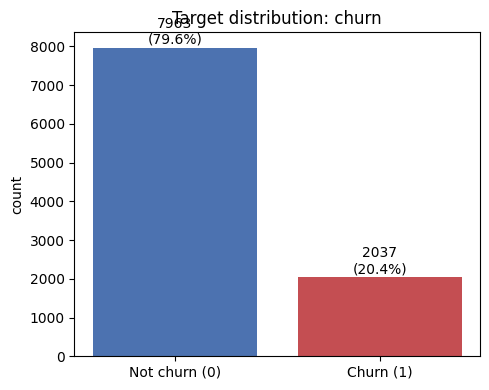

In [17]:
fig, ax = plt.subplots(figsize=(5, 4))
vc = base["churn"].value_counts().sort_index()
ax.bar(["Not churn (0)", "Churn (1)"], vc.values, color=["#4C72B0", "#C44E52"])
for i, v in enumerate(vc.values):
    ax.text(i, v + 100, f"{v}\n({v/len(base)*100:.1f}%)", ha="center")
ax.set_title("Target distribution: churn"); ax.set_ylabel("count")
plt.tight_layout(); plt.savefig("../outputs/figures/target_distribution.png", dpi=120); plt.show()

=> **[OBSERVATION]** Churn = 20.37% (2,037/10,000) — **dữ liệu mất cân bằng** (~1:4). Hệ quả cho bước modeling: (1) dùng `class_weight` hoặc SMOTE (fit trên train fold only), (2) ưu tiên **Recall + AUC-PR** thay vì Accuracy để đánh giá model — khớp với cost framing đã chốt trong research plan (bỏ sót 1 khách churn tốn kém hơn false alarm).

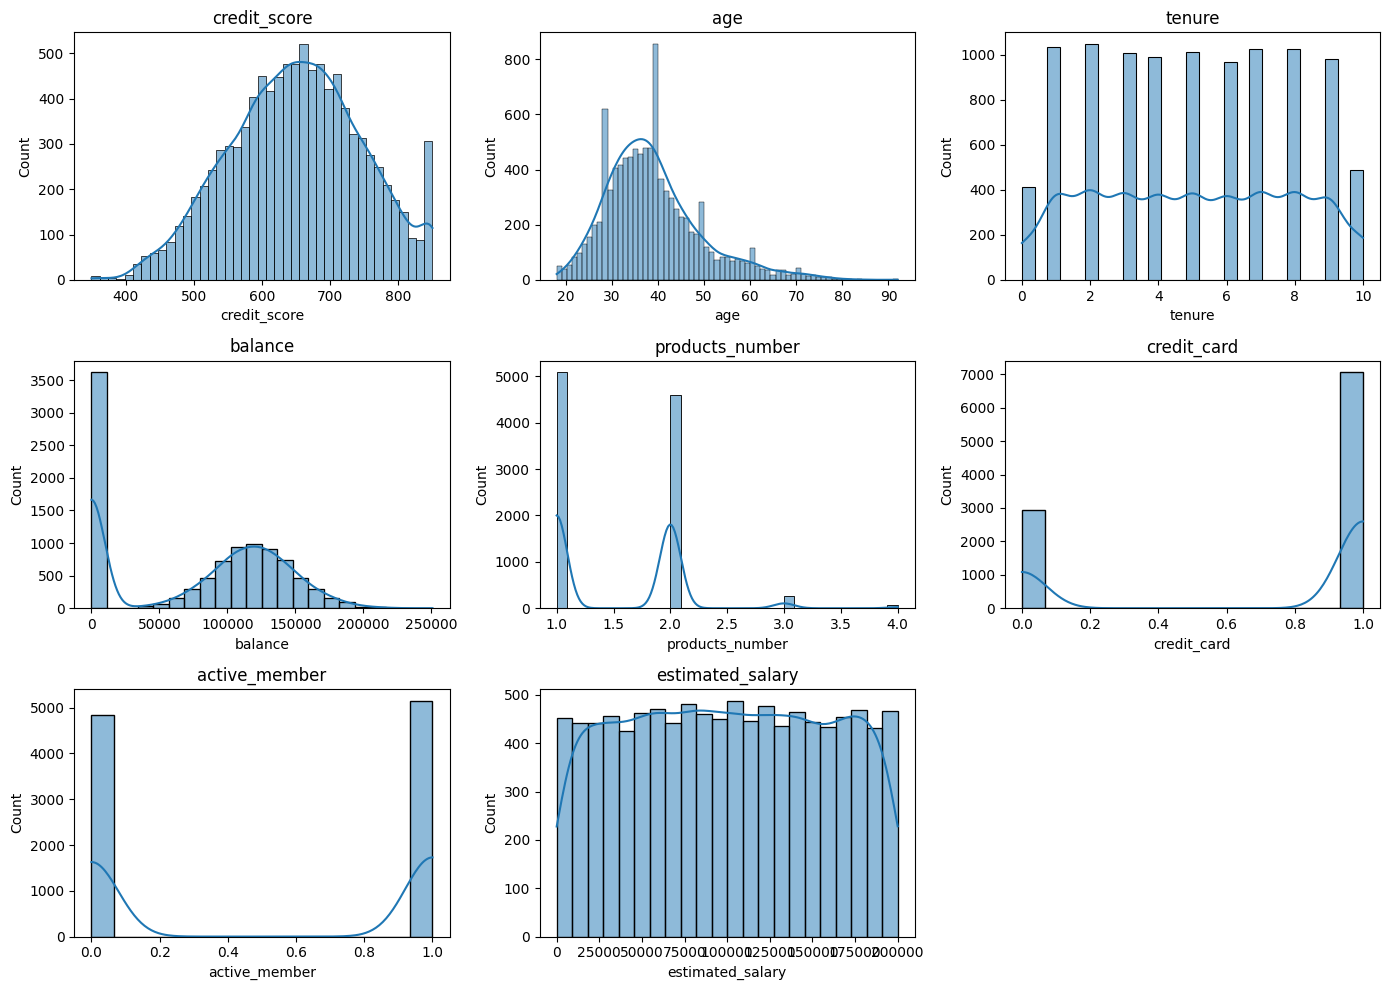

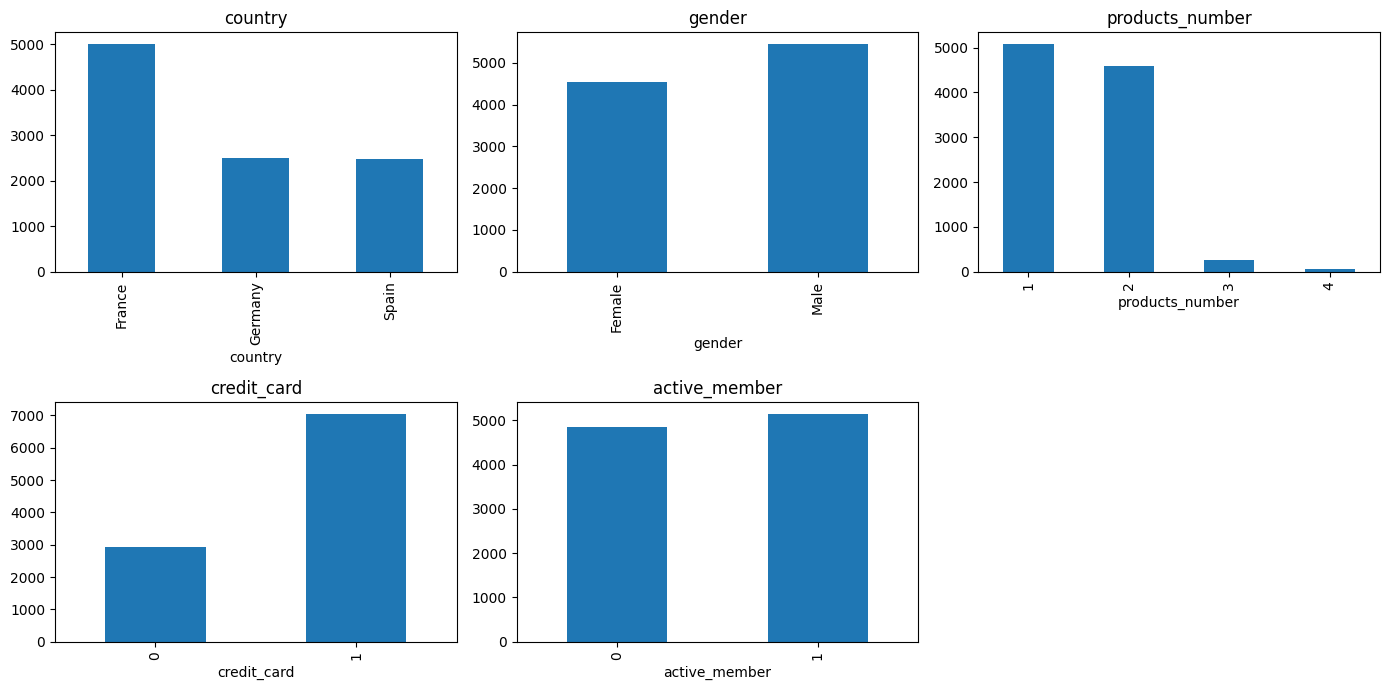

In [18]:
numeric_cols = [c for c in base.select_dtypes(include=np.number).columns if c not in ("customer_id", "churn")]
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(base[col], kde=True, ax=ax); ax.set_title(col)
for ax in axes.flat[len(numeric_cols):]:
    ax.axis("off")
plt.tight_layout(); plt.savefig("../outputs/figures/univariate_numeric.png", dpi=120); plt.show()

cat_cols = ["country", "gender", "products_number", "credit_card", "active_member"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, cat_cols):
    base[col].value_counts().sort_index().plot(kind="bar", ax=ax); ax.set_title(col)
for ax in axes.flat[len(cat_cols):]:
    ax.axis("off")
plt.tight_layout(); plt.savefig("../outputs/figures/univariate_categorical.png", dpi=120); plt.show()

=> **[OBSERVATION]** `age` lệch phải, tập trung 30–40 tuổi; `balance` có khối lượng lớn tại 0 rồi mới trải rộng (không phải phân phối chuẩn đơn đỉnh); `products_number` tập trung ở 1–2, rất ít khách có 3–4 sản phẩm; `country` lệch về France (~50%). Cần xem tiếp churn rate theo từng nhóm nhỏ này ở bước sau.


-- churn_rate(%) by country --
         churn_rate  count
country                   
France        16.15   5014
Germany       32.44   2509
Spain         16.67   2477

-- churn_rate(%) by gender --
        churn_rate  count
gender                   
Female       25.07   4543
Male         16.46   5457

-- churn_rate(%) by products_number --
                 churn_rate  count
products_number                   
1                     27.71   5084
2                      7.58   4590
3                     82.71    266
4                    100.00     60

-- churn_rate(%) by active_member --
               churn_rate  count
active_member                   
0                   26.85   4849
1                   14.27   5151

-- churn_rate(%) by age_band --
          churn_rate  count
age_band                   
18-29           7.56   1641
30-39          10.88   4346
40-49          30.79   2618
50-59          56.04    869
60+            27.95    526


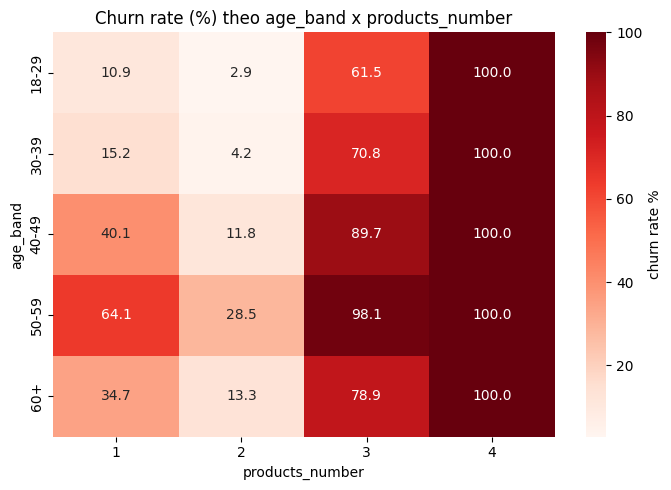

In [19]:
base["age_band"] = pd.cut(base["age"], bins=[17, 29, 39, 49, 59, 100],
                          labels=["18-29", "30-39", "40-49", "50-59", "60+"])

for col in ["country", "gender", "products_number", "active_member", "age_band"]:
    t = base.groupby(col, observed=True)["churn"].agg(["mean", "count"]).rename(columns={"mean": "churn_rate"})
    t["churn_rate"] = (t["churn_rate"] * 100).round(2)
    print(f"\n-- churn_rate(%) by {col} --")
    print(t.to_string())

pivot = pd.pivot_table(base, index="age_band", columns="products_number", values="churn", aggfunc="mean", observed=True) * 100
pivot = pivot.round(1)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Reds", ax=ax, cbar_kws={"label": "churn rate %"})
ax.set_title("Churn rate (%) theo age_band x products_number")
plt.tight_layout(); plt.savefig("../outputs/figures/churn_rate_pivot_age_products.png", dpi=120); plt.show()

=> **[OBSERVATION]** Đây là nhóm insight mạnh nhất của bộ dữ liệu:
- **Germany** churn 32.44% — cao gấp đôi France (16.15%) và Spain (16.67%).
- **Nữ** churn 25.07% > **Nam** 16.46%.
- **products_number**: 1→27.71%, 2→7.58% (thấp nhất), 3→82.71% (266 khách), **4→100%** (60 khách) — gần như tách biệt hoàn toàn nhưng chỉ chiếm 3.26% tổng số khách.
- **active_member=0** churn 26.85% > **active_member=1** 14.27%.
- **age_band 50-59** churn cao nhất (56.04%); kết hợp với products_number=3 lên tới **98.1%** (xem heatmap).

=> **[HYPOTHESIS]** Nhóm 3–4 sản phẩm có thể là khách bị cross-sell quá mức, hoặc đây là đặc điểm riêng của bộ dữ liệu gốc (Kaggle) chứ không phản ánh hành vi thực tế phổ biến — **chưa kết luận nhân quả**, cần xác nhận với business owner trước khi dùng làm căn cứ hành động, và cần thận khi model vì subgroup quá nhỏ (60–266 khách) dễ gây overfit nếu không regularize.

In [22]:
def cramers_v(ctab):
    chi2 = stats.chi2_contingency(ctab)[0]
    n = ctab.to_numpy().sum(); r, k = ctab.shape
    return float(np.sqrt(chi2 / (n * (min(r, k) - 1))))

def eta_squared(groups):
    all_vals = np.concatenate(groups); grand_mean = all_vals.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_total = ((all_vals - grand_mean) ** 2).sum()
    return float(ss_between / ss_total)

results = []
for col in base.columns:
    if col in ("churn", "age_band"): continue
    s = base[col]
    # Kiểm tra nếu cột là kiểu số (int, float)
    if pd.api.types.is_numeric_dtype(s):
        groups = [base.loc[base.churn == c, col].values for c in sorted(base.churn.unique())]
        f, p = stats.f_oneway(*groups)
        results.append((col, "anova", eta_squared(groups), "eta_squared", f, p))
    else:
        # Xử lý như biến phân loại (bao gồm object, category, datetime, ...)
        ctab = pd.crosstab(s, base["churn"])
        chi2, p, dof, exp = stats.chi2_contingency(ctab)
        results.append((col, "chi2", cramers_v(ctab), "cramers_v", chi2, p))

drivers = pd.DataFrame(results, columns=["feature", "test", "effect_size", "effect_name", "stat", "p_value"])
drivers["significant"] = drivers["p_value"] < 0.05
drivers.sort_values("effect_size", ascending=False).reset_index(drop=True)

,feature,test,effect_size,effect_name,stat,p_value,significant
0,account_open_date,chi2,0.579598,cramers_v,3359.343234,4.417201e-01,False
1,country,chi2,0.173567,cramers_v,301.255337,3.830318e-66,True
2,gender,chi2,0.106263,cramers_v,112.918571,2.248210e-26,True
3,age,anova,0.081409,eta_squared,886.063275,1.239931e-186,True
4,active_member,anova,0.024376,eta_squared,249.800794,1.348269e-55,True
5,balance,anova,0.014050,eta_squared,142.473832,1.275563e-32,True
6,products_number,anova,0.002287,eta_squared,22.915223,1.717333e-06,True
7,credit_score,anova,0.000734,eta_squared,7.344522,6.738214e-03,True
8,tenure,anova,0.000196,eta_squared,1.960164,1.615268e-01,False
9,estimated_salary,anova,0.000146,eta_squared,1.463262,2.264404e-01,False


=> **[OBSERVATION]** Xếp hạng theo effect size: `country` (Cramér's V=0.173) > `gender` (0.106) > `age` (η²=0.081) > `active_member` (0.024) > `balance` (0.014) > `products_number` (η²=0.0023, **thấp dù chênh lệch churn rate rất lớn**). `tenure`, `estimated_salary`, `credit_card`, `customer_id` không có ý nghĩa thống kê (p>0.05) — `customer_id` đúng như kỳ vọng (sanity check pass, vì chỉ là ID).

=> **Bẫy thống kê cần tránh:** `products_number` xếp hạng thấp theo ANOVA dù pivot table cho thấy ảnh hưởng cực mạnh, vì hiệu ứng dồn vào một subgroup rất nhỏ (3–4 sản phẩm, 3.26% khách hàng) khiến ANOVA trung bình hóa trên toàn bộ bị pha loãng. **Đọc effect size cùng với pivot table**, không chỉ nhìn ranking tổng.

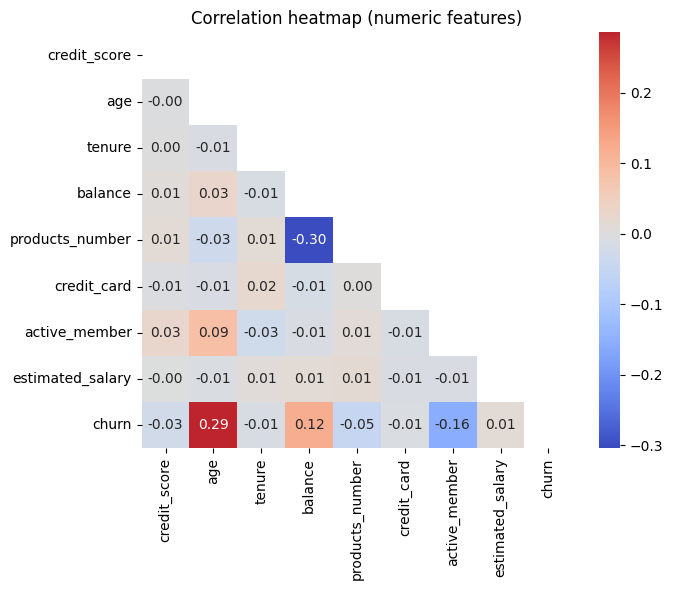

Khong co cap numeric nao |r| > 0.5
Series([], dtype: float64)


In [23]:
num_for_corr = base.select_dtypes(include=np.number).drop(columns=["customer_id"])
corr = num_for_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation heatmap (numeric features)")
plt.tight_layout(); plt.savefig("../outputs/figures/corr_heatmap_pearson.png", dpi=120); plt.show()

# Collinearity check: cap nao |r| > 0.5 (ngoai duong cheo)
pairs = corr.where(~mask).stack()
pairs = pairs[pairs.index.get_level_values(0) != pairs.index.get_level_values(1)]
strong = pairs[pairs.abs() > 0.5].sort_values(ascending=False)
print("Cap co |r| > 0.5:" if len(strong) else "Khong co cap numeric nao |r| > 0.5")
print(strong)

=> **[OBSERVATION]** Không có cặp biến numeric nào |r| > 0.5 — không có vấn đề đa cộng tuyến (collinearity) đáng lo ngại giữa các biến số hiện có. Điều này cũng cố thêm rằng các biến đầu vào độc lập tương đối với nhau, không cần prune ở bước feature selection sau này vì lý do collinearity (vẫn có thể prune vì lý do effect size thấp, nhưng đó là quyết định khác).

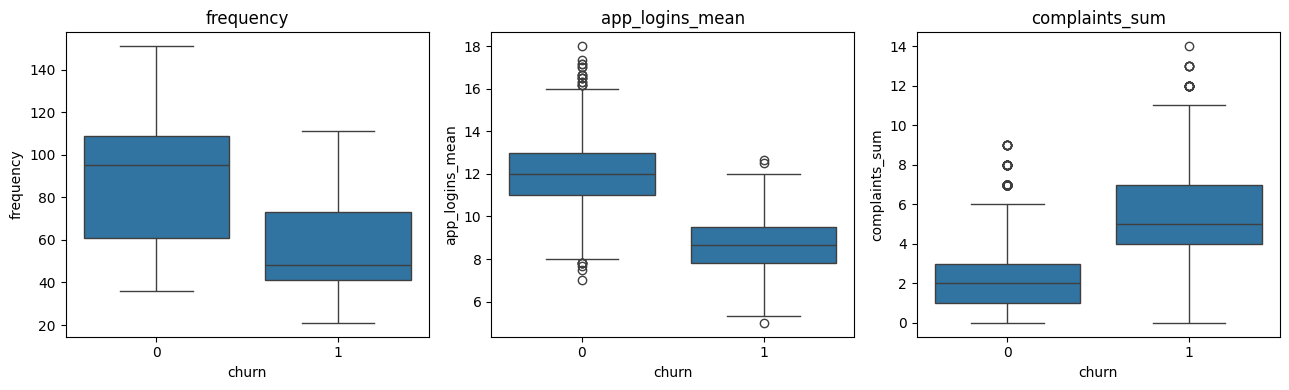

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, ["frequency", "app_logins_mean", "complaints_sum"]):
    sns.boxplot(data=customer_panel, x="churn", y=col, ax=ax); ax.set_title(col)
plt.tight_layout(); plt.savefig("../outputs/figures/behavioral_by_churn.png", dpi=120); plt.show()

=> **[OBSERVATION]** Boxplot xác nhận lại bằng số đã tính ở bước Data Collection: nhóm churn có `frequency`/`app_logins_mean` thấp hơn và `complaints_sum` cao hơn rõ ràng, phân phối tách biệt nhưng vẫn overlap (không leak). => **[HYPOTHESIS]** xu hướng giảm giao dịch/đăng nhập có thể là tín hiệu cảnh báo sớm (early-warning) trước khi khách thực sự rời đi — nhưng **vì đây là dữ liệu synthetic được thiết kế sẵn theo logic này**, kết luận này chỉ có giá trị minh họa phương pháp (proof of concept), **không phải bằng chứng thực tế** — cần thay bằng dữ liệu giao dịch thật trước khi dùng để quyết định retention thật.

### Definition of Done — Data Requirement / Collection / Understanding

- [x] Xác định được input thiếu (timestamp/hành vi) và generate bằng Faker + business logic, có anti-leakage check
- [x] Phát hiện và fix lỗi FK integrity của file synthetic có sẵn (0% → 100% overlap)
- [x] Gộp thành 1 bảng customer-level (`data/processed/eda_customer_panel.parquet`) với RFM + engagement, khớp `config.yaml`
- [x] ≥ 5 insight được gỏi rõ observation/hypothesis, kèm chứng cứ số liệu và chart (lưu trong `research/outputs/figures/`)
- [x] Không có kết luận nhân quả nào được đưa ra từ correlation/pivot đơn thuần
- [ ] Xác nhận với business owner ý nghĩa thực của nhóm products_number=3-4 (100% churn) trước khi đưa vào model
- [ ] Thay dữ liệu hành vi synthetic bằng dữ liệu giao dịch thật khi có

**Next step:** chuyển sang phần `Data preparing` (missing/outlier handling, encoding, feature engineering: `zero_balance`, `balance_to_salary_ratio`, xử lý class imbalance) đã có sẵn header bên dưới.

# 🔶 Data preparing

blah blah blah...

# 🔶 Modeling

blah blah blah...

# 🔶 Evaluation

blah blah blah...

# 🔶 Deployment (Pipeline)

blah blah blah...

# 🔶 Inference

blah blah blah...